
*********************************************
*     Tester la troisieme loi de Kepler     *
*             et peser un astre             *
*********************************Hatier 2020*

**** Astre etudie: Jupiter ****
**** Trace de ln(T) en fonction de ln(a) ****
Coefficient directeur de la regression
m= 1.503E+00 USI
Ordonnee a l'origine de la regression
p= -1.792E+01 USI

Masse tabulee de l'astre attracteur
M= 1.898E+27 kg
Masse calculee de l'astre attracteur
M= 2.176E+27 kg
Ecart-relatif 14.647418141623344


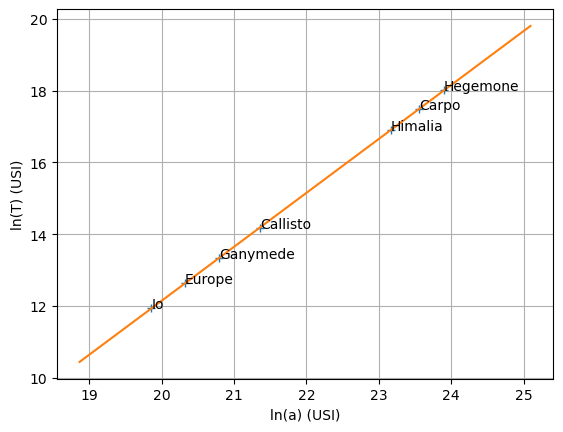

In [9]:
from pylab import *
from math import *
from scipy.stats import linregress
import numpy as np
import numpy.polynomial.polynomial as nppol

print("")
print("*********************************************")
print("*     Tester la troisieme loi de Kepler     *")
print("*             et peser un astre             *")
print("*********************************Hatier 2020*")
print("")

#########################################
### DONNEES A MODIFIER (Question 1.a) ###
#########################################

### Nom de l'astre attracteur
nomastre="Jupiter"
### Masse tabulee de l'astre attracteur en kg
M=1.898e27

### Liste des noms des satellites (entre "")
satellites=["Io","Europe","Ganymede","Callisto","Himalia","Carpo","Hegemone"]
### Liste des demi-grands axes en km
a=[421800,671100,1070400,1882700,11461000,16989000,23947000]
### Liste des periodes orbitales en j
T=[1.769,3.551,7.155,16.689,251.73,456.1,769.6]

### Donnees a ne pas modifier
### Constante de la gravitation universelle en USI
G=6.67e-11
### Initialisation des grandeurs et des tableaux
x=np.zeros(len(satellites))
y=np.zeros(len(satellites))

###############################
### A MODIFIER (Question 3) ###
###############################
tracelog=True


################################
### A MODIFIER (Question 2a) ###
################################
### Liste des T carres et des a cubes en USI
for i in range(len(a)):
	x[i]=(a[i]*1000)**3
	y[i]=float((T[i]*86400)**2)

### Ne pas modifier
### Regression lineaire (fonction lineaire)
reg=nppol.polyfit(x,y,[1])

if tracelog==True:
	for i in range(len(a)):
		x[i]=log(a[i]*1000)
		y[i]=log(T[i]*86400)
### Regression lineaire (fonction affine)
	reg=nppol.polyfit(x,y,[0,1])

##m,p,rho,_,_=linregress(x,y)

m=reg[1]
p=reg[0]

################################
### A MODIFIER (Question 2b) ###
################################
Mcalc=(4*pi**2)/(G*m)

typereg="Trace de T^2 en fonction de a^3"
if tracelog==True:
	Mcalc=4*pi**2/(G*e**(2*p))
	typereg="Trace de ln(T) en fonction de ln(a)"

print("**** Astre etudie:",nomastre,"****")
print("****",typereg,"****")
print("Coefficient directeur de la regression")
print("m=",format(m,"4.3E"),"USI")
if tracelog==True:
	print("Ordonnee a l'origine de la regression")
	print("p=",format(p,"4.3E"),"USI")
print("")
print("Masse tabulee de l'astre attracteur")
print("M=",format(M,"4.3E"),"kg")
print("Masse calculee de l'astre attracteur")
print("M=",format(Mcalc,"4.3E"),"kg")

ecart_relatif = (abs(Mcalc - M) / M)*100
print("Ecart-relatif",ecart_relatif)

xmin=0
xmax=1.05*max(x)
if tracelog==True:
	xmin=0.95*min(x)

xmodele=[xmin,xmax]
ymodele=[m*xmin+p,m*xmax+p]

xlabel("a^3 (m^3)")
ylabel("T^2 (s^2)")

if tracelog==True:
	xlabel("ln(a) (USI)")	
	ylabel("ln(T) (USI)")
plot(x,y,"+")
for i in range(len(a)):
	annotate(satellites[i],(x[i],y[i]))
plot(xmodele,ymodele)
grid(True)
show()

